# Heuristics Analysis (old)

Interim testing of the intial heuristics and their performance against true values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Datasets/Aggregation_methods.csv', encoding='utf-8')
df.head()

,ID,sent_id,annotation_utt_score,annotation_sent,mean,median,position_avg,length_avg,intensity_avg,diff_mean,diff_median,diff_position,diff_length,diff_intensity
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.seg398.1,2.0,2.240412,2.838881,2.636969,3.072022,2.808230,2.960941,0.838881,0.636969,1.072022,0.808230,0.960941
1,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.seg398.2,2.0,2.636969,2.838881,2.636969,3.072022,2.808230,2.960941,0.838881,0.636969,1.072022,0.808230,0.960941
2,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.seg398.3,2.0,3.639261,2.838881,2.636969,3.072022,2.808230,2.960941,0.838881,0.636969,1.072022,0.808230,0.960941
3,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.seg382.1,3.0,4.084590,3.491818,3.340636,3.319424,3.265585,3.546158,0.491818,0.340636,0.319424,0.265585,0.546158
4,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.seg383.1,3.0,3.340636,3.491818,3.340636,3.319424,3.265585,3.546158,0.491818,0.340636,0.319424,0.265585,0.546158


## Differences between aggregation methods

Inspection of differences between individual methods and checking for possible trends within the newly aggregated sentiment scores on the utterance level.

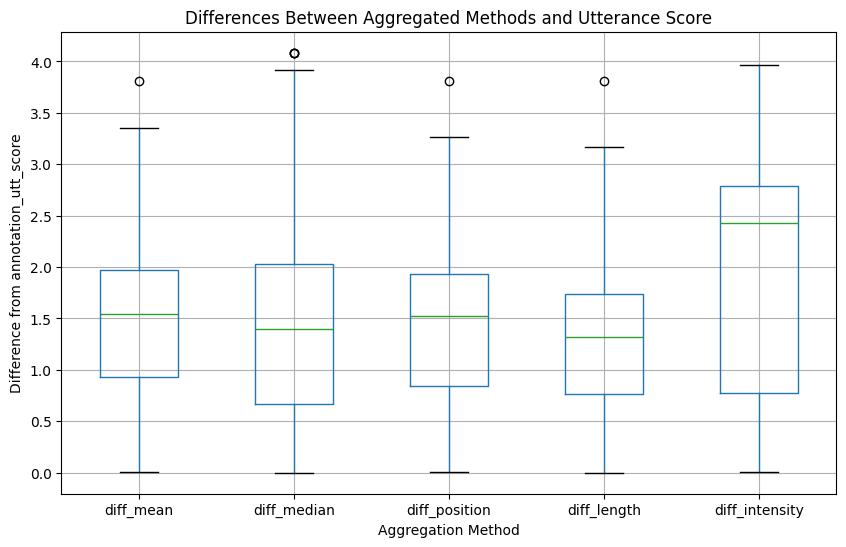

In [3]:
#Boxplot figure to inspect the differences between the aggregation methods
fig, ax = plt.subplots(figsize = (10,6))
diff_columns = ['diff_mean', 'diff_median', 'diff_position', 'diff_length', 'diff_intensity']
df[diff_columns].boxplot(ax=ax)
ax.set_title('Differences Between Aggregated Methods and Utterance Score')
ax.set_ylabel('Difference from annotation_utt_score')
ax.set_xlabel('Aggregation Method')
plt.savefig('../Figures/Boxplot_differences.png', dpi=300)
plt.show()

With the lowest differences and the median closest to 0 (as well as the lowest average difference of 1.252, calculated during aggregation method testing), ```length_avg/length_diff``` seems to be the best method so far.

## Plot of grouped averages
Plotting the percentiles for each method (or rather, their scores) and the human-annotation scores to compare the distribution of scores.

In [4]:
unique_df = df.drop_duplicates(subset="ID", keep="first").reset_index(drop=True)
methods = ['ID','mean', 'median', 'position_avg', 'length_avg', 'intensity_avg', 'annotation_utt_score']
unique_df = unique_df[methods]
unique_df


,ID,mean,median,position_avg,length_avg,intensity_avg,annotation_utt_score
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,2.838881,2.636969,3.072022,2.808230,2.960941,2.0
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,3.491818,3.340636,3.319424,3.265585,3.546158,3.0
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,3.235311,3.166192,3.250870,3.053920,3.400855,5.0
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,1.978221,1.869849,2.118181,1.757866,2.982718,0.0
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,3.156749,3.156749,3.156749,3.156749,3.156749,3.0
...,...,...,...,...,...,...,...
795,ParlaMint-SI_2020-11-16-SDZ8-Izredna-48.u284,2.330899,2.520191,1.954460,1.675302,3.089447,0.0
796,ParlaMint-SI_2014-03-03-SDZ6-Redna-22.u242,3.167355,3.063763,3.077388,3.024682,3.438531,1.0
797,ParlaMint-SI_2001-10-05-SDZ3-Redna-08.u73,2.082792,2.082792,2.082792,2.082792,2.082792,3.0
798,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.u95,3.084250,3.250649,3.058486,2.490833,3.294399,3.0


In [5]:
import numpy as np

percentiles = unique_df[["mean", "median", "position_avg", "length_avg", "intensity_avg", "annotation_utt_score"]].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
percentiles

,mean,median,position_avg,length_avg,intensity_avg,annotation_utt_score
0.10,1.878783,1.741537,1.792038,1.391687,2.711005,0.0
0.25,2.438046,2.593496,2.397629,2.178716,2.997404,0.0
0.50,3.109645,3.087712,3.095868,2.926002,3.321081,3.0
0.75,3.537773,3.536198,3.445394,3.300574,3.650524,3.0
0.90,3.777721,3.789236,3.695077,3.646659,3.847637,4.0


## Line plot (Score percentiles)

Inpecting the score percentiles to identify the trends within different aggregation methods and comparing them with the ```annotation_utt_score``` scores (which represent the scores that were assigned to the utterances by the human annotators) 

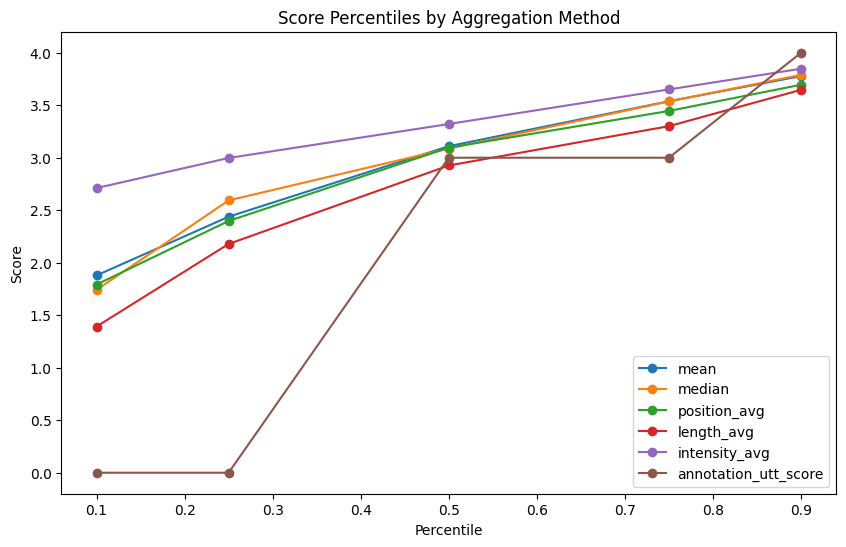

In [6]:
plt.figure(figsize=(10, 6))

for method in percentiles.columns:
    plt.plot(percentiles.index, percentiles[method], marker='o', label=method)

# Labeling
plt.xlabel("Percentile")
plt.ylabel("Score")
plt.title("Score Percentiles by Aggregation Method")
plt.legend()
plt.savefig('../Figures/Score_percentiles.png', dpi=300)
plt.show()

The percentile score plot suggest that the ```mean```, ```median```, ```position_avg```and ```length_avg``` produce similar results across, as the lines are closely aligned (and overlap at certain points), while the ```intensity_avg``` produces the highest score, indicating that weights might be overemphasising certain aspects/scores. In addition, human annotation scores (```annotation_utt_score```) also reveals very sharp trends (could mean a number of things in relation to the data and annotation process), but make sense (e.g., 50th precentile/median concentrating on around 2.8, which would mathc with the large amount of N_Neutral annotation due to large amount of procedural data), and the two extremes (negative, positive)

In [ ]:
melted_df = unique_df.melt(value_vars=["mean", "median", "position_avg", "length_avg", "intensity_avg", "annotation_utt_score"], 
                           var_name="Method", value_name="Score")

#melted_df.to_csv("../Datasets/Scores_check.csv", encoding='utf-8', index=False)
melted_df

,Method,Score
0,mean,2.838881
1,mean,3.491818
2,mean,3.235311
3,mean,1.978221
4,mean,3.156749
...,...,...
4795,annotation_utt_score,0.000000
4796,annotation_utt_score,1.000000
4797,annotation_utt_score,3.000000
4798,annotation_utt_score,3.000000


## Historigrams of individual method score distributions

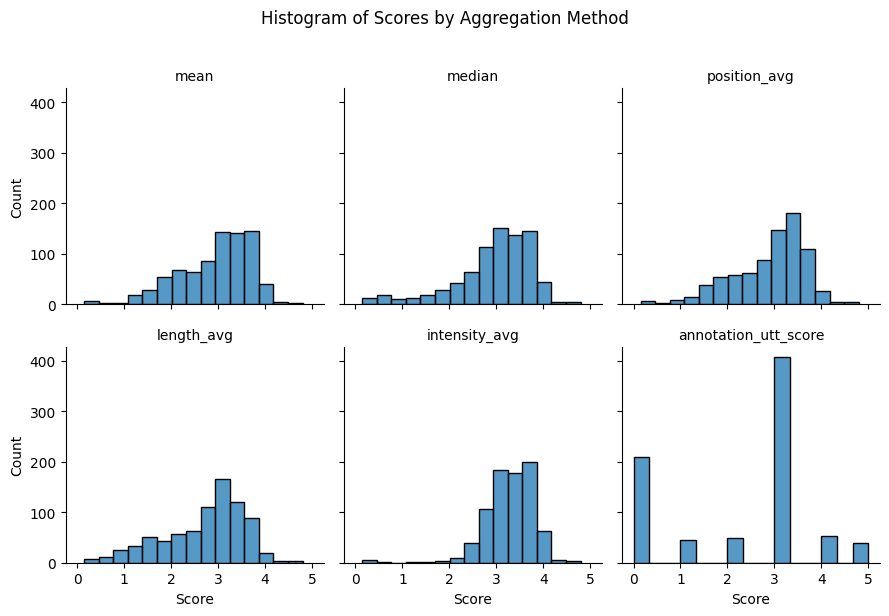

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = sns.FacetGrid(melted_df, col="Method", col_wrap=3, height=3, sharey=True)
fig.map(sns.histplot, "Score", bins=15)

fig.set_titles("{col_name}")
fig.set_axis_labels("Score", "Count")
plt.suptitle("Histogram of Scores by Aggregation Method", y=1.02)
plt.tight_layout()
plt.savefig('../Figures/Score_Histograms.png', dpi=300)
plt.show()

The histograms show the distribution of scores by individual aggregation method in comparison to the distribution of the human annotations (```annotation_utt_score```). One of the more problematic aspects is the low amount of the Negative labels (which is very prominent with the human annotations, but not so much once aggregated, as the extreme values seem to be lost). Should probably be addressed further.